# Python statsmodels 多変量ロジスティック回帰分析 
## チュートリアル　By ChatGPT

***
statsmodelsの現行APIに沿って、多変量ロジスティック回帰を実務で再現できる流れに整理します。モデル作成からオッズ比、p値・信頼区間、予測性能、カテゴリ変数や多重共線性の確認まで含めます。

以下では、「目的変数が 0/1 の二値アウトカム」「説明変数が複数ある」ロジスティック回帰を想定します。日本語でよくいう「多変量ロジスティック回帰」は、多くの場合この **multivariable logistic regression**、つまり「複数の説明変数で調整したロジスティック回帰」を指します。目的変数が 3 カテゴリ以上なら `MNLogit` など別モデルになります。

statsmodels は統計モデル推定、仮説検定、統計的な結果表示に強いライブラリで、ロジスティック回帰では `statsmodels.formula.api.logit()` または `statsmodels.api.Logit()` を使えます。公式ドキュメント上の現在の安定版は statsmodels 0.14.6 です

https://www.statsmodels.org/stable/index.html

https://www.statsmodels.org/stable/generated/statsmodels.formula.api.logit.html

https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html

***
### 1. まず全体像

ロジスティック回帰では、次の形のモデルを推定します。

$\log \big( \frac{p}{1 - p} \big) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_k x_k$

ここで、

$p = P(Y=1)$

です。

たとえば、

> event = 1 : 疲労あり 
>
> event = 0 : 疲労なし

と定義した場合、モデルは **「疲労ありになる確率**」 を説明します。

係数 $\beta_j$はそのままだと **対数オッズの変化量** です。実務では、多くの場合、

$\exp(β_j)$

を計算して **オッズ比 OR** として解釈します。

***
### 2. インストールと読み込み

#### ライブラリのインストール
> pip install pandas numpy statsmodels scikit-learn matplotlib

***
#### 読み込み

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt

statsmodels では R 風の formula、つまり `'目的変数 ~ 説明変数1 + 説明変数2'` のような書き方ができます。

formula API は内部的に Patsy を使って、データフレームから設計行列を作ります。

カテゴリ変数を扱いやすいため、最初は `statsmodels.formula.api` を使うのがおすすめです。
https://www.statsmodels.org/stable/examples/notebooks/generated/formulas.html
https://www.statsmodels.org/stable/generated/statsmodels.formula.api.logit.html

***
### 3. 練習用データを作る

実データがある場合はこの部分を `pd.read_csv()` などに置き換えてください。ここでは、HRV・疲労スコア・年齢・性別から、二値アウトカム `event` を説明する例にします

In [2]:
rng = np.random.default_rng(42)

n = 300

df = pd.DataFrame({
    "age": rng.normal(45, 12, n).clip(18, 80),
    "RMSSD": rng.lognormal(mean=3.4, sigma=0.35, size=n),
    "VAS_fatigue": rng.uniform(0, 100, n),
    "sex": rng.choice(["female", "male"], size=n)
})

# 真の発生確率を仮に作る
linear_pred = (
    -1.5
    + 0.04  * (df["age"] - 45)
    - 0.025 * (df["RMSSD"] - df["RMSSD"].mean())
    + 0.025 * (df["VAS_fatigue"] - 50)
    + 0.35  * (df["sex"] == "male")
)

p = 1 / (1 + np.exp(-linear_pred))

df["event"] = rng.binomial(1, p, size=n)

df.head()

,age,RMSSD,VAS_fatigue,sex,event
0,48.656605,54.848376,41.157600,female,0
1,32.520191,17.516591,79.368215,female,0
2,54.005414,40.542054,8.481927,female,0
3,56.286777,26.709416,55.546171,female,0
4,21.587578,29.327818,80.205979,female,0


目的変数は必ず **0/1** にしておきます。

In [3]:
display(df["event"].unique())
display(df["event"].value_counts())
display(df.describe())

array([0, 1])

event
0    230
1     70
Name: count, dtype: int64

,age,RMSSD,VAS_fatigue,event
count,300.000000,300.000000,300.000000,300.000000
mean,44.519719,31.755918,48.691666,0.233333
std,11.130868,11.290522,29.855149,0.423659
min,18.000000,10.616559,0.123306,0.000000
25%,36.967624,23.384450,23.372150,0.000000
50%,43.956115,30.604886,48.067737,0.000000
75%,50.684277,37.972778,74.569105,0.000000
max,79.966350,74.379904,99.874337,1.000000


***
### 4. 前処理：連続変数の単位を考える

ロジスティック回帰の係数は「説明変数が 1 単位増えたとき」の効果です。

たとえば、

> age: 1歳あたり
> 
> RMSSD: 1 ms あたり
> 
> VAS_fatigue: 1点あたり

だと、オッズ比が細かすぎて解釈しづらいことがあります。

そこで、臨床的・実務的に意味のある単位に変換します。

In [4]:
df["age_10"] = df["age"] / 10
df["RMSSD_10"] = df["RMSSD"] / 10
df["VAS_10"] = df["VAS_fatigue"] / 10

これで、

> age_10    : 10歳あたり
> 
> RMSSD_10  : 10 ms あたり
> 
> VAS_10    : 10点あたり

として解釈できます。

***
### 5. 多変量ロジスティック回帰を実行する

formula API では次のように書きます。

In [5]:
formula = "event ~ age_10 + RMSSD_10 + VAS_10 + C(sex)"

model = smf.logit(formula=formula, data=df)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.490113
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  event   No. Observations:                  300
Model:                          Logit   Df Residuals:                      295
Method:                           MLE   Df Model:                            4
Date:                Mon, 18 May 2026   Pseudo R-squ.:                 0.09785
Time:                        13:51:42   Log-Likelihood:                -147.03
converged:                       True   LL-Null:                       -162.98
Covariance Type:            nonrobust   LLR p-value:                 2.009e-06
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.6542      0.839     -3.165      0.002      -4.298      -1.011
C(sex)[T.male]   

`smf.logit()` は formula と DataFrame から Logit モデルを作る関数です。`Logit.fit()` は最大尤度法でモデルを推定します。

https://www.statsmodels.org/stable/generated/statsmodels.formula.api.logit.html

https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html

ここで、

`C(sex)`

は `sex` をカテゴリ変数として扱う指定です。たとえば `sex` が `female` / `male` なら、どちらか一方が基準カテゴリになり、もう一方との差が推定されます。

基準カテゴリを明示したい場合は、次のように書けます。

In [6]:
formula = "event ~ age_10 + RMSSD_10 + VAS_10 + C(sex, Treatment(reference='female'))"

result = smf.logit(formula=formula, data=df).fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.490113
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  event   No. Observations:                  300
Model:                          Logit   Df Residuals:                      295
Method:                           MLE   Df Model:                            4
Date:                Mon, 18 May 2026   Pseudo R-squ.:                 0.09785
Time:                        13:51:42   Log-Likelihood:                -147.03
converged:                       True   LL-Null:                       -162.98
Covariance Type:            nonrobust   LLR p-value:                 2.009e-06
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                             

***
### 6. 結果の読み方

`summary()` には、おおむね次の情報が出ます。

| カラム名 | 内容 |
|:----:|:---- |
| coef | 回帰係数。<br>対数オッズ比 |
| std err  | 標準誤差 |
| z | Wald統計量 |
| P>\|z\|  | p値 |
| [0.025, 0.975]  | 係数の95%信頼区間 |

ロジスティック回帰では、`coef` をそのまま読むより、指数変換してオッズ比にする方が解釈しやすいです。

In [7]:
params = result.params
conf = result.conf_int()

or_table = pd.DataFrame({
    "coef": params,
    "OR": np.exp(params),
    "CI_lower": np.exp(conf[0]),
    "CI_upper": np.exp(conf[1]),
    "p_value": result.pvalues
})

or_table

,coef,OR,CI_lower,CI_upper,p_value
Intercept,-2.654238,0.070352,0.013597,0.363999,0.001550
"C(sex, Treatment(reference='female'))[T.male]",0.239910,1.271134,0.719447,2.245866,0.408734
age_10,0.261151,1.298424,1.000813,1.684534,0.049289
RMSSD_10,-0.344943,0.708261,0.533362,0.940512,0.017135
VAS_10,0.225132,1.252488,1.132085,1.385697,0.000013


`LogitResults` には、係数の信頼区間を作る `conf_int()`、p値、標準誤差、AIC、BIC、擬似R²、予測、限界効果などを取得する機能があります。

https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.LogitResults.html

***
### 7. オッズ比の解釈

たとえば、出力が次のようになったとします。

> RMSSD_10 の OR = 0.78

このとき、

> 年齢、疲労VAS、性別を一定にしたとき、
> 
> RMSSDが10 ms高い人では、event=1となるオッズが0.78倍

と解釈します。

つまり、`event=1` が「疲労あり」なら、

> RMSSDが高いほど、疲労ありのオッズが低い

という方向です。

一方で、

> VAS_10 の OR = 1.35

なら、

> 年齢、RMSSD、性別を一定にしたとき、
> 
> VAS疲労スコアが10点高い人では、event=1となるオッズが1.35倍

です。

重要なのは、**何を event=1 にしたか** です。

> event = 1 : 疲労あり

なら「疲労ありのオッズ」を説明します。

> event = 1 : 対照群

なら「対照群であるオッズ」を説明します。

目的変数の 0/1 を逆にすると、係数の符号は反転し、オッズ比はおおむね逆数になります。

***
### 8. p値の解釈

各説明変数の p値は、基本的に次の仮説を検定しています。

$H_0:\beta_j=0$

これはオッズ比で言えば、

$H_0:\exp(\beta_j)=1$

です。

つまり、

>その説明変数は、他の説明変数で調整したあと、
>
>event=1 のオッズと関連しない

という帰無仮説です。

p値が小さい場合は、

>その変数の係数は0とは言いにくい

つまり、

調整後にも event=1 のオッズと関連していそう

と読みます。

ただし、p値は「効果の大きさ」ではありません。実務では、p値だけでなく、

>OR
>
>95%信頼区間
>
>臨床的・業務的に意味のある大きさか
>
>サンプルサイズ
>
>交絡の可能性
>
>モデルの妥当性

を一緒に見ます。

***
### 9. 予測確率を出す

学習データに対する予測確率は次のように出せます。

In [8]:
df["pred_prob"] = result.predict(df)
df[["event", "pred_prob"]].head()

,event,pred_prob
0,0,0.087151
1,0,0.349245
2,0,0.079336
3,0,0.298363
4,0,0.214767


In [9]:
new_data = pd.DataFrame({
    "age_10": [4.0, 6.0],          # 40歳, 60歳
    "RMSSD_10": [3.0, 2.0],        # 30 ms, 20 ms
    "VAS_10": [2.0, 7.0],          # VAS 20点, 70点
    "sex": ["female", "male"]
})

pred = result.predict(new_data)
pred

0    0.100273
1    0.509653
dtype: float64

これは、

> event=1 になる予測確率

です。

***
### 10. 0/1分類に変換する

ロジスティック回帰の直接の出力は確率です。

分類したい場合は、しきい値を決めます。

In [10]:
threshold = 0.5
df["pred_class"] = (df["pred_prob"] >= threshold).astype(int)
confusion_matrix(df["event"], df["pred_class"])

array([[227,   3],
       [ 62,   8]])

見やすくします。

In [11]:
cm = pd.DataFrame(
    confusion_matrix(df["event"], df["pred_class"]),
    index=["observed_0", "observed_1"],
    columns=["pred_0", "pred_1"]
)

cm

,pred_0,pred_1
observed_0,227,3
observed_1,62,8


statsmodels 側にも、指定した threshold で予測表を作る `pred_table()` があります。`pred_table[i, j]` は「実測 i、予測 j」の件数を表し、対角成分が正解数です

In [12]:
result.pred_table(threshold=0.5)

array([[227.,   3.],
       [ 62.,   8.]])

ただし、しきい値 0.5 は常に最適とは限りません。疾患スクリーニングのように感度を重視するのか、偽陽性を減らしたいのかで、適切なしきい値は変わります。

***
### 11. ROC曲線とAUC

分類性能を見るなら ROC曲線とAUCを確認します。

In [13]:
auc = roc_auc_score(df["event"], df["pred_prob"])
auc

0.7150310559006211

ROC曲線を描きます。

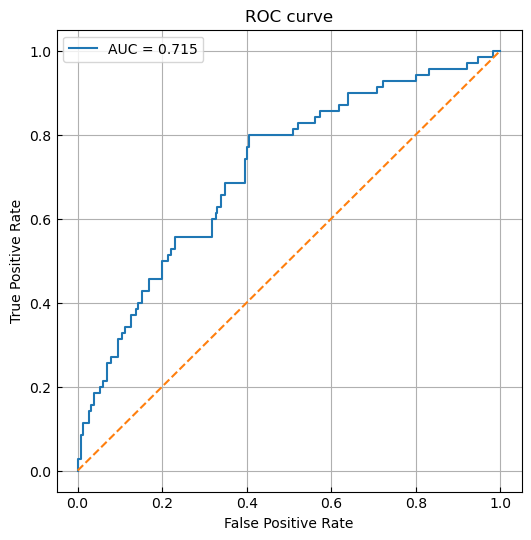

In [14]:
fpr, tpr, thresholds = roc_curve(df["event"], df["pred_prob"])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.tick_params(direction='in')
plt.grid()
plt.show()

注意点として、学習データでそのままAUCを見ると楽観的になりやすいです。予測性能を評価したい場合は、訓練データとテストデータに分けるか、交差検証を使います。

***
### 12. 訓練データ・テストデータに分ける例

統計的推論、つまり OR や p値を見たい場合は、最終的には全データでモデルを推定することも多いです。一方で、予測性能を見たい場合は、テストデータで評価します。

In [15]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["event"]
)

formula = "event ~ age_10 + RMSSD_10 + VAS_10 + C(sex)"

result_train = smf.logit(formula=formula, data=train_df).fit()

test_df = test_df.copy()
test_df["pred_prob"] = result_train.predict(test_df)

test_auc = roc_auc_score(test_df["event"], test_df["pred_prob"])
test_auc

Optimization terminated successfully.
         Current function value: 0.483933
         Iterations 6


0.6742581090407178

***
### 13. GLM Binomial を使う書き方

statsmodels では、ロジスティック回帰を GLM、つまり一般化線形モデルとして書くこともできます。GLM は二項分布 `Binomial()` を含む指数型分布族を扱います。

In [16]:
glm_result = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial()
).fit()

print(glm_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  event   No. Observations:                  300
Model:                            GLM   Df Residuals:                      295
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -147.03
Date:                Mon, 18 May 2026   Deviance:                       294.07
Time:                        13:51:42   Pearson chi2:                     313.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1009
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.6542      0.839     -3.

個票データの二値アウトカムで、リンク関数が logit の場合、`smf.logit()` と `smf.glm(..., family=sm.families.Binomial())` はかなり近い目的で使えます。

実務的には、まずは次の使い分けでよいです。

> 通常の二値ロジスティック回帰
> 
> → smf.logit()
>
> GLMの枠組みで扱いたい、二項分布以外のモデルも比較したい
> 
> → smf.glm(..., family=sm.families.Binomial())

***
### 14. 限界効果を見る

オッズ比は便利ですが、「確率が何ポイント変わるか」は直接は表しません。

たとえば OR = 2 でも、もともとの確率が 1% なのか 50% なのかで、確率差の印象は大きく変わります。

そこで、限界効果を見ます。

In [17]:
marginal_effects = result.get_margeff(at="overall")
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:                  event
Method:                          dydx
At:                           overall
                                                   dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
C(sex, Treatment(reference='female'))[T.male]     0.0384      0.046      0.829      0.407      -0.052       0.129
age_10                                            0.0418      0.021      2.004      0.045       0.001       0.083
RMSSD_10                                         -0.0552      0.023     -2.449      0.014      -0.099      -0.011
VAS_10                                            0.0360      0.007      4.824      0.000       0.021       0.051


`get_margeff()` は fitted model の限界効果を取得するメソッドで、`dydx` は説明変数の変化に対する目的変数の変化として解釈されます。二値変数を 0 から 1 への変化として扱いたい場合は `dummy=True` を指定できます。
https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.LogitResults.get_margeff.html

In [18]:
marginal_effects_dummy = result.get_margeff(at="overall", dummy=True)
print(marginal_effects_dummy.summary())

        Logit Marginal Effects       
Dep. Variable:                  event
Method:                          dydx
At:                           overall
                                                   dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
C(sex, Treatment(reference='female'))[T.male]     0.0384      0.046      0.828      0.407      -0.052       0.129
age_10                                            0.0418      0.021      2.004      0.045       0.001       0.083
RMSSD_10                                         -0.0552      0.023     -2.449      0.014      -0.099      -0.011
VAS_10                                            0.0360      0.007      4.824      0.000       0.021       0.051


大まかには、

> オッズ比
> → event=1 のオッズが何倍か
>
> 限界効果
> → event=1 の予測確率が平均的に何ポイント変わるか

です。

説明相手が統計に慣れていない場合、限界効果の方が伝わりやすいことがあります。

***
### 15. 多重共線性を確認する

説明変数同士が強く相関していると、係数やp値が不安定になります。

VIFを計算する例です。

In [19]:
import patsy
from statsmodels.stats.outliers_influence import variance_inflation_factor

formula_rhs = "age_10 + RMSSD_10 + VAS_10 + C(sex)"

X = patsy.dmatrix(formula_rhs, data=df, return_type="dataframe")

vif_table = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_table

,variable,VIF
0,Intercept,29.618625
1,C(sex)[T.male],1.008899
2,age_10,1.001112
3,RMSSD_10,1.013411
4,VAS_10,1.004808


`Intercept` のVIFは通常あまり気にしません。

VIFが高い場合は、次のような対応を検討します。

> 似た変数を同時に入れすぎていないか確認する
> 
> 臨床的・理論的に重要な変数を優先する
> 
> 合成スコアや主成分を検討する
> 
> 変数選択の目的を明確にする

***
### 16. 連続変数の線形性を疑う

ロジスティック回帰は、確率そのものではなく **logit、つまり対数オッズに対して線形** という仮定を置きます。

たとえば、

> 年齢が10歳増えるたび、対数オッズが一定量増える

という仮定です。

これが怪しい場合は、二次項やスプラインを試します。

#### 二次項の例

In [20]:
formula_poly = "event ~ age_10 + I(age_10**2) + RMSSD_10 + VAS_10 + C(sex)"

result_poly = smf.logit(formula=formula_poly, data=df).fit()

print(result_poly.summary())

Optimization terminated successfully.
         Current function value: 0.489978
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  event   No. Observations:                  300
Model:                          Logit   Df Residuals:                      294
Method:                           MLE   Df Model:                            5
Date:                Mon, 18 May 2026   Pseudo R-squ.:                 0.09810
Time:                        13:51:42   Log-Likelihood:                -146.99
converged:                       True   LL-Null:                       -162.98
Covariance Type:            nonrobust   LLR p-value:                 6.004e-06
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.1784      1.853     -1.176      0.240      -5.810       1.453
C(sex)[T.male]   

#### スプラインの例

In [21]:
formula_spline = "event ~ bs(age_10, df=4) + RMSSD_10 + VAS_10 + C(sex)"

result_spline = smf.logit(formula=formula_spline, data=df).fit()

print(result_spline.summary())

Optimization terminated successfully.
         Current function value: 0.485118
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  event   No. Observations:                  300
Model:                          Logit   Df Residuals:                      292
Method:                           MLE   Df Model:                            7
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.1070
Time:                        13:51:42   Log-Likelihood:                -145.54
converged:                       True   LL-Null:                       -162.98
Covariance Type:            nonrobust   LLR p-value:                 1.171e-05
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -1.6778      1.446     -1.160      0.246      -4.512       1.156
C(

`bs()` は Patsy の関数です。formula API では Patsy の機能を利用して設計行列を作るため、こうした柔軟な指定が可能です。
https://www.statsmodels.org/stable/examples/notebooks/generated/formulas.html

***
### 17. モデル比較

説明変数を変えた複数モデルを比較することがあります。

In [22]:
model1 = smf.logit(
    "event ~ age_10 + C(sex)",
    data=df
).fit()

model2 = smf.logit(
    "event ~ age_10 + C(sex) + RMSSD_10 + VAS_10",
    data=df
).fit()

print("model1 AIC:", model1.aic)
print("model2 AIC:", model2.aic)

print("model1 BIC:", model1.bic)
print("model2 BIC:", model2.bic)

Optimization terminated successfully.
         Current function value: 0.536704
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.490113
         Iterations 6
model1 AIC: 328.0222724088017
model2 AIC: 304.0680158668616
model1 BIC: 339.1336198327703
model2 BIC: 322.5869282401426


AICやBICは小さい方が相対的に良いとされます。ただし、機械的に最小のものを選ぶのではなく、

> 目的
> 
> 解釈可能性
> 
> 過学習
> 
> サンプルサイズ
> 
> 交絡調整として必要な変数
> 
> 事前仮説

を考慮します。

***
### 18. よくあるエラーと対処
#### 18.1 PerfectSeparationError

完全分離、またはそれに近い状態です。

たとえば、ある変数の値によって event=1 と event=0 が完全に分かれてしまうと、係数が無限大方向に発散します。

よくある原因は次です。

> サンプルサイズが小さい
> 
> 説明変数が多すぎる
> 
> カテゴリ変数の水準が細かすぎる
> 
> あるカテゴリで event=1 または event=0 しか存在しない

確認例：

In [23]:
pd.crosstab(df["sex"], df["event"])

event,0,1
sex,,
female,118,31
male,112,39


カテゴリが多い変数なら、

In [24]:
df

,age,RMSSD,VAS_fatigue,sex,event,age_10,RMSSD_10,VAS_10,pred_prob,pred_class
0,48.656605,54.848376,41.157600,female,0,4.865660,5.484838,4.115760,0.087151,0
1,32.520191,17.516591,79.368215,female,0,3.252019,1.751659,7.936822,0.349245,0
2,54.005414,40.542054,8.481927,female,0,5.400541,4.054205,0.848193,0.079336,0
3,56.286777,26.709416,55.546171,female,0,5.628678,2.670942,5.554617,0.298363,0
4,21.587578,29.327818,80.205979,female,0,2.158758,2.932782,8.020598,0.214767,0
...,...,...,...,...,...,...,...,...,...,...
295,47.118149,25.835194,9.697789,female,0,4.711815,2.583519,0.969779,0.109429,0
296,48.551928,24.972970,84.579696,female,1,4.855193,2.497297,8.457970,0.414944,0
297,40.537025,39.821639,61.675618,male,0,4.053703,3.982164,6.167562,0.207378,0
298,23.919339,32.608758,54.236440,male,0,2.391934,3.260876,5.423644,0.155322,0


In [25]:
pd.crosstab(df["VAS_10"], df["event"])

event,0,1
VAS_10,,
0.012331,0,1
0.016607,1,0
0.040076,1,0
0.045001,1,0
0.047414,1,0
...,...,...
9.917745,1,0
9.930846,1,0
9.947017,0,1


対処としては、

> カテゴリを統合する
> 
> 説明変数を減らす
> 
> データ数を増やす
> 
> 正則化ロジスティック回帰を検討する

などがあります。

statsmodels の `Logit` には正則化推定用の `fit_regularized()` もあります。ただし、通常の `fit()` で得る p値や信頼区間と同じ感覚で解釈しない方が安全です。

https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html

In [26]:
result_reg = smf.logit(formula=formula, data=df).fit_regularized(alpha=1.0)
result_reg.params

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5008427532528879
            Iterations: 33
            Function evaluations: 35
            Gradient evaluations: 33


Intercept        -1.878636
C(sex)[T.male]    0.098802
age_10            0.161483
RMSSD_10         -0.382065
VAS_10            0.205016
dtype: float64

***
#### 18.2 `Singular matrix`

説明変数に完全な重複がある、またはダミー変数を入れすぎている可能性があります。

たとえば、カテゴリ変数を自分で one-hot encoding して、全カテゴリのダミーを入れたうえで切片も入れると、完全共線性が起きます。

formula API の `C()` を使うと、通常は基準カテゴリを自動的に落としてくれるため、この問題を避けやすいです。

***
#### 欠損値がある

まず確認します。

In [27]:
df.isna().sum()

age            0
RMSSD          0
VAS_fatigue    0
sex            0
event          0
age_10         0
RMSSD_10       0
VAS_10         0
pred_prob      0
pred_class     0
dtype: int64

単純に欠損を除外するなら、

In [28]:
analysis_df = df.dropna(subset=[
    "event", "age_10", "RMSSD_10", "VAS_10", "sex"
])

ただし、欠損が多い場合や欠損の仕方に意味がある場合は、単純な complete case analysis ではバイアスが出ることがあります。

***
### 19. 実務での最小テンプレート

実データに対してまず走らせるなら、次のテンプレートが使いやすいです。

In [30]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, confusion_matrix

# 1. データ読み込み
# df = pd.read_csv("your_data.csv")

# 2. 目的変数を0/1にする
# 例: fatigueありを1、なしを0にする
# df["event"] = df["fatigue_status"].map({"no": 0, "yes": 1})

# 3. 解釈しやすい単位に変換
df["age_10"] = df["age"] / 10
df["RMSSD_10"] = df["RMSSD"] / 10
df["VAS_10"] = df["VAS_fatigue"] / 10

# 4. 解析に使う列だけ抽出して欠損除外
analysis_df = df[[
    "event",
    "age_10",
    "RMSSD_10",
    "VAS_10",
    "sex"
]].dropna()

# 5. モデル推定
formula = "event ~ age_10 + RMSSD_10 + VAS_10 + C(sex)"

result = smf.logit(formula=formula, data=analysis_df).fit()

print(result.summary())

# 6. OR表を作る
params = result.params
conf = result.conf_int()

or_table = pd.DataFrame({
    "coef": params,
    "OR": np.exp(params),
    "CI_lower": np.exp(conf[0]),
    "CI_upper": np.exp(conf[1]),
    "p_value": result.pvalues
})

print(or_table)

# 7. 予測確率
analysis_df["pred_prob"] = result.predict(analysis_df)

# 8. AUC
auc = roc_auc_score(analysis_df["event"], analysis_df["pred_prob"])
print("AUC:", auc)

# 9. 混同行列
analysis_df["pred_class"] = (analysis_df["pred_prob"] >= 0.5).astype(int)

cm = confusion_matrix(analysis_df["event"], analysis_df["pred_class"])
print(cm)

Optimization terminated successfully.
         Current function value: 0.490113
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  event   No. Observations:                  300
Model:                          Logit   Df Residuals:                      295
Method:                           MLE   Df Model:                            4
Date:                Mon, 18 May 2026   Pseudo R-squ.:                 0.09785
Time:                        13:51:45   Log-Likelihood:                -147.03
converged:                       True   LL-Null:                       -162.98
Covariance Type:            nonrobust   LLR p-value:                 2.009e-06
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.6542      0.839     -3.165      0.002      -4.298      -1.011
C(sex)[T.male]   

***
### 20. レポートに書くときの例
たとえば次のように書けます。

> event=1を「疲労あり」と定義し、年齢、性別、RMSSD、VAS疲労スコアを説明変数とする多変量ロジスティック回帰分析を行った。連続変数は解釈しやすいように、年齢は10歳単位、RMSSDは10 ms単位、VAS疲労スコアは10点単位に変換した。
> 
> RMSSD_10の調整オッズ比は0.78であり、年齢、性別、VAS疲労スコアを調整したうえで、RMSSDが10 ms高い場合、疲労ありのオッズは0.78倍であった。
>
> VAS_10の調整オッズ比は1.35であり、他の変数を調整したうえで、VAS疲労スコアが10点高い場合、疲労ありのオッズは1.35倍であった。

実際には、次のように信頼区間とp値も併記します。

> RMSSD_10: OR = 0.78, 95% CI 0.65–0.93, p = 0.006
> 
> VAS_10: OR = 1.35, 95% CI 1.12–1.63, p = 0.002

***
### 21. 重要なチェックリスト

最後に、statsmodels で多変量ロジスティック回帰を進めるときの実務チェックリストです。

> 1. event=1 が何を意味するか明確にする
> 2. 目的変数が0/1になっているか確認する
> 3. 連続変数の単位を解釈しやすくする
> 4. カテゴリ変数は C() で扱う
> 5. OR = exp(coef) を出す
> 6. 95%信頼区間も exp() してORの信頼区間にする
> 7. p値は「β=0、つまりOR=1」の検定として読む
> 8. 欠損値を確認する
> 9. 多重共線性を確認する
> 10. 完全分離や収束警告を確認する
> 11. AUCや混同行列を見る場合は、可能ならテストデータで評価する
> 12. 予測性能と統計的推論を混同しない

まずは `smf.logit()` でモデルを作り、`summary()`、OR表、予測確率、AUC、限界効果の順に確認していくのが最もわかりやすい進め方です。